### Implementing Simple Chatbot using langgraph 

In [15]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [16]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [17]:
from langchain_groq import ChatGroq
import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

llm.invoke("Hello How are you doing ?")

AIMessage(content='Hello! I’m doing great, thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello How are you doing ?" It\'s a casual greeting. We should respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 77, 'total_tokens': 129, 'completion_time': 0.108428719, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.002863928, 'prompt_tokens_details': None, 'queue_time': 0.3171519, 'total_time': 0.111292647}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08f56-e04b-7723-a99c-c74599b498d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 52, 'total_tokens': 129, 'output_token_details': {'reasoning': 25}})

In [18]:
def superbot(state:State):
    return {"messages":llm.invoke(state['messages'])}

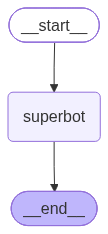

In [19]:
from IPython.display import Image,display

graph = StateGraph(State)
graph.add_node("superbot",superbot)
graph.add_edge(START , "superbot")
graph.add_edge("superbot",END)
graph_builder=graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:
graph_builder.invoke({"messages":"Hello what can you help me with"})

{'messages': [HumanMessage(content='Hello what can you help me with', additional_kwargs={}, response_metadata={}, id='318e9d3f-83fe-45b8-9b24-17e3748ff129'),
  AIMessage(content='Hello! I’m ChatGPT, an AI language model here to help with a wide variety of tasks. Some of the things I can assist you with include:\n\n- **Answering questions** – from general knowledge and current events (up to my 2024 knowledge cutoff) to more specialized topics like science, history, technology, literature, and more.  \n- **Explaining concepts** – breaking down complex ideas into simpler, easy‑to‑understand explanations.  \n- **Writing and editing** – drafting emails, letters, essays, reports, blog posts, stories, poems, scripts, and other creative pieces; polishing existing text for clarity, tone, grammar, and style.  \n- **Learning support** – helping you study, solve practice problems, generate study guides, or brainstorm project ideas.  \n- **Programming help** – explaining code, debugging, writing sn

### Streaming a response 

In [21]:
for event in graph_builder.stream({"messages":"Hello what can you help me with"}):
    print(event)

{'superbot': {'messages': AIMessage(content='Hello! I’m here to help with a wide range of tasks, such as:\n\n- **Answering questions** – from everyday facts to deeper explanations in science, history, technology, and more.  \n- **Learning & tutoring** – breaking down complex concepts, walking through math problems, language learning, etc.  \n- **Writing & editing** – drafting emails, essays, stories, reports, resumes, social‑media posts, or polishing existing text.  \n- **Creative brainstorming** – generating ideas for projects, marketing copy, plot twists, game mechanics, recipes, and more.  \n- **Programming assistance** – explaining code, debugging, writing snippets in many languages, helping with algorithms or software design.  \n- **Research support** – summarizing information, comparing options, outlining pros/cons, or pointing you toward useful resources.  \n- **Practical help** – planning schedules, making checklists, offering travel tips, budgeting ideas, etc.  \n\nIf you have